In [22]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch

project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    src_candidate = base / "src" / "trajectoryclusteringanalysis"
    if src_candidate.exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find project root containing src/trajectoryclusteringanalysis from {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Using local package from: {src_path}")

from trajectoryclusteringanalysis.tca import TCA

Using local package from: c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src


In [23]:
df = pd.read_csv(project_root / "data" / "multidimensional_data.csv")
df

,PATIENT_ID,EVENT,TIME
0,1,Chirurgie,0
1,1,Chimiothérapie IV,1
2,1,Chimiothérapie IV,1
3,1,Chimiothérapie IV,2
4,1,Chimiothérapie IV,3
...,...,...,...
20430,1336,Chimiothérapie IV,2
20431,1336,Chimiothérapie IV,2
20432,1336,Chimiothérapie IV,3
20433,1336,Chimiothérapie IV,3


In [24]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
timed_event_structure = df.copy()

timed_event_structure['Event'] = label_encoder.fit_transform(timed_event_structure['EVENT'])
timed_event_structure.drop(columns=['EVENT'], inplace=True)
timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']
noms_events = label_encoder.classes_
timed_event_structure

,ID_PATIENT,Time,Event
0,1,0,2
1,1,1,0
2,1,1,0
3,1,2,0
4,1,3,0
...,...,...,...
20430,1336,2,0
20431,1336,2,0
20432,1336,3,0
20433,1336,3,0


In [25]:
nunique = timed_event_structure['ID_PATIENT'].nunique()
print(f"Number of unique patients: {nunique}")

Number of unique patients: 1336


In [26]:
# Get the set of all unique Event values
unique_events = timed_event_structure['Event'].unique()
all_events = set(unique_events)

# Find patients who have all occurrences of Event
patients_with_all_events = timed_event_structure.groupby('ID_PATIENT').filter(
    lambda group: set(group['Event']) == all_events
)['ID_PATIENT'].unique()

print(f"Patients with all occurrences of Event: {len(patients_with_all_events)}")
print(patients_with_all_events)

Patients with all occurrences of Event: 50
[   8   23   45   65   66  134  157  173  176  178  188  194  220  228
  242  275  312  343  361  390  428  466  469  472  478  537  544  546
  575  613  665  673  688  759  775  790  792  831  845  867  895  937
  943  969  984 1081 1126 1286 1293 1333]


In [27]:
# Créer une instance de TCA pour l'analyse multidimensionnelle
tca = TCA(data=timed_event_structure,
              index_col='ID_PATIENT',
              time_col='Time', 
              event_col='Event',
              mode='multidimensional',
              )

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


In [28]:
tca.analyzer.transform_time_event_structure_to_tensor()
print("Tensor shape:", tca.analyzer.get_tensor_shape())
tensor = tca.analyzer.get_tensor()

Tensor shape: torch.Size([1336, 4, 24])


Patient utilise pour la visualisation: 8


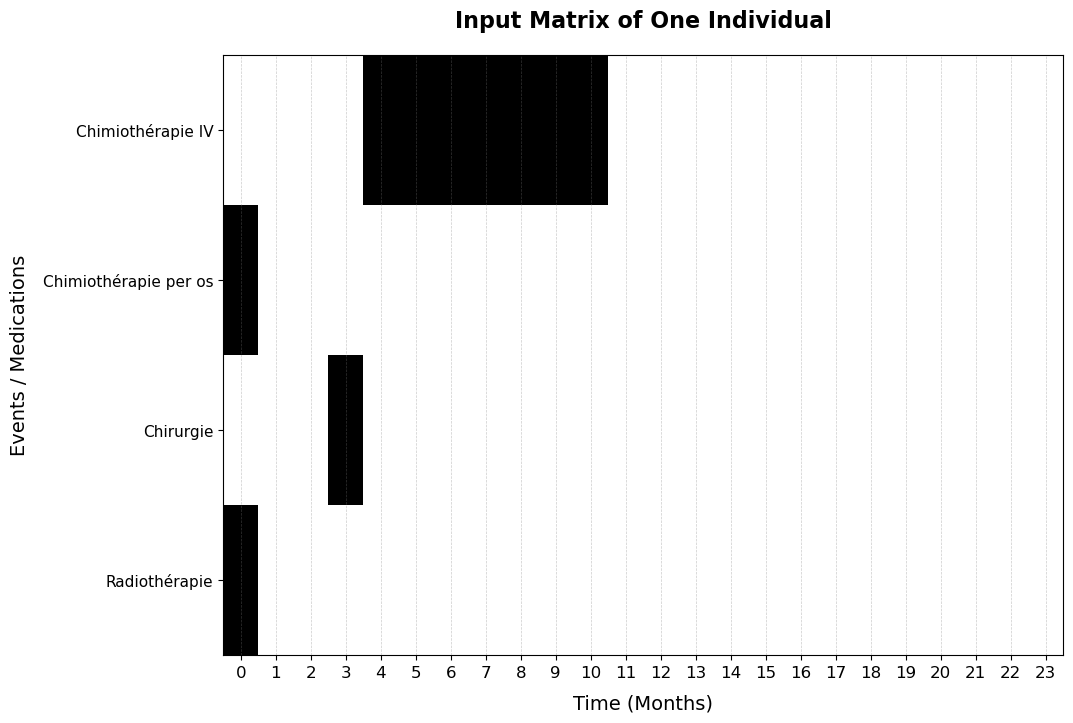

     PATIENT_ID                  EVENT  TIME
143           8  Chimiothérapie per os     0
144           8          Radiothérapie     0
145           8          Radiothérapie     0
146           8          Radiothérapie     0
147           8          Radiothérapie     0
148           8          Radiothérapie     0
149           8          Radiothérapie     0
150           8          Radiothérapie     0
151           8              Chirurgie     3
152           8              Chirurgie     3
153           8      Chimiothérapie IV     4
154           8      Chimiothérapie IV     5
155           8      Chimiothérapie IV     6
156           8      Chimiothérapie IV     6
157           8      Chimiothérapie IV     7
158           8      Chimiothérapie IV     7
159           8      Chimiothérapie IV     7
160           8      Chimiothérapie IV     8
161           8      Chimiothérapie IV     8
162           8      Chimiothérapie IV     9
163           8      Chimiothérapie IV     9
164       

In [52]:
patient_index = int(patients_with_all_events[0])
print(f"Patient utilise pour la visualisation: {patient_index}")

plot_input_matrix(tensor, id=patient_index, labels=noms_events, time_unit="Months")

print(df[df['PATIENT_ID'] == 8])

In [30]:
# Hyperparametres de la demo
rank = 3
reg_term_ns = 0.5
reg_term_s = 0.5
metric = 'Bernoulli'
learning_rate = 1e-3
n_epochs = 5  # 30 pour demo rapide, 100+ pour entrainement plus stable

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 36     | n/a   | n/a  
--------------------------------------

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


Decomposed into 1336 pathways with rank 3 and time window length 3
FIT metric for the entire dataset: -1.3642
success_rate :-1.5883450835154096


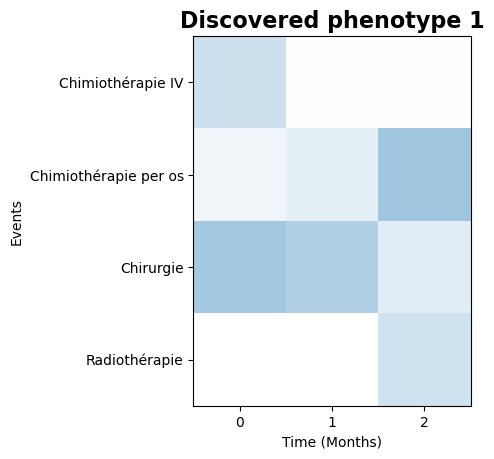

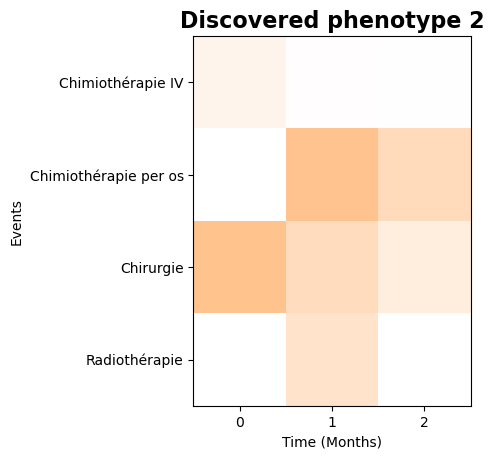

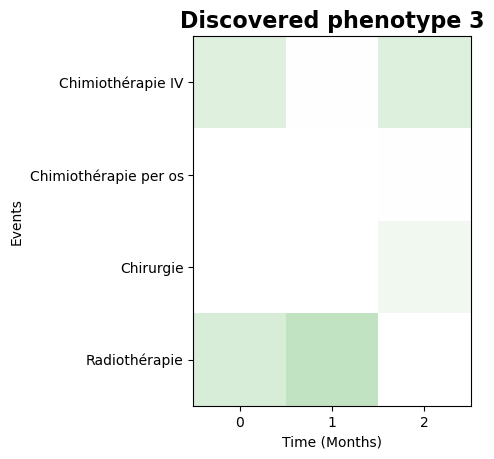

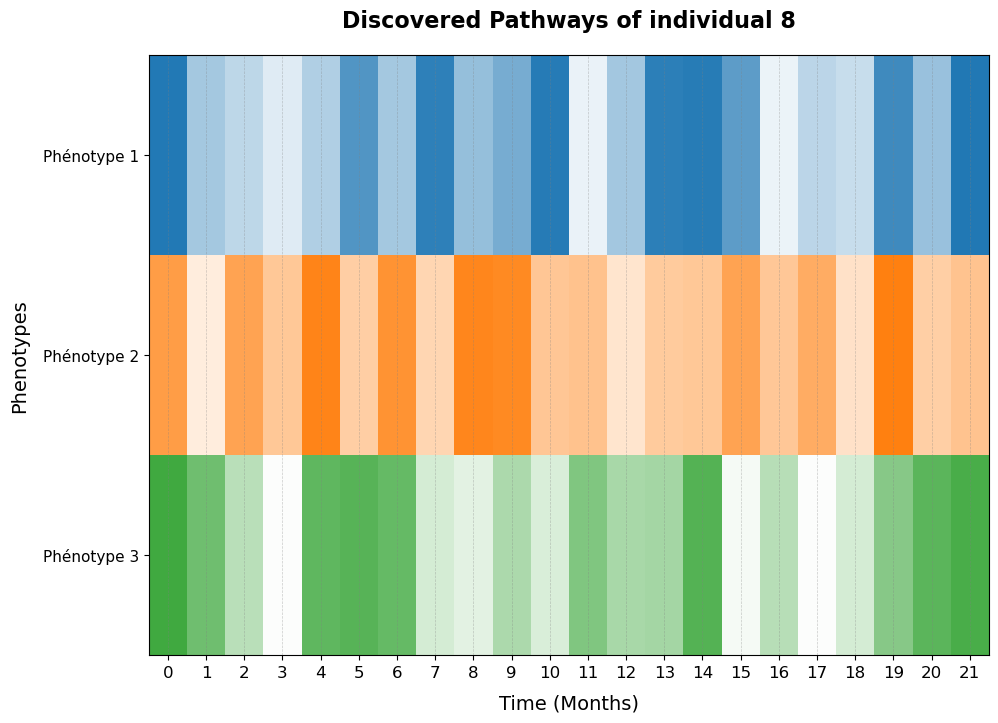

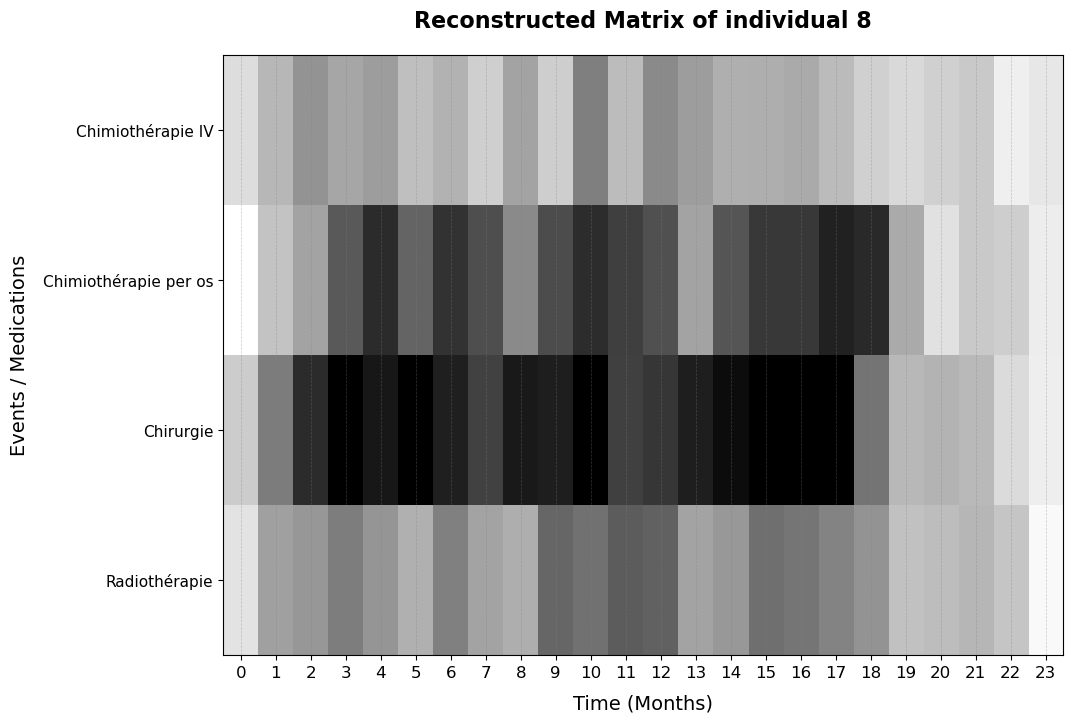

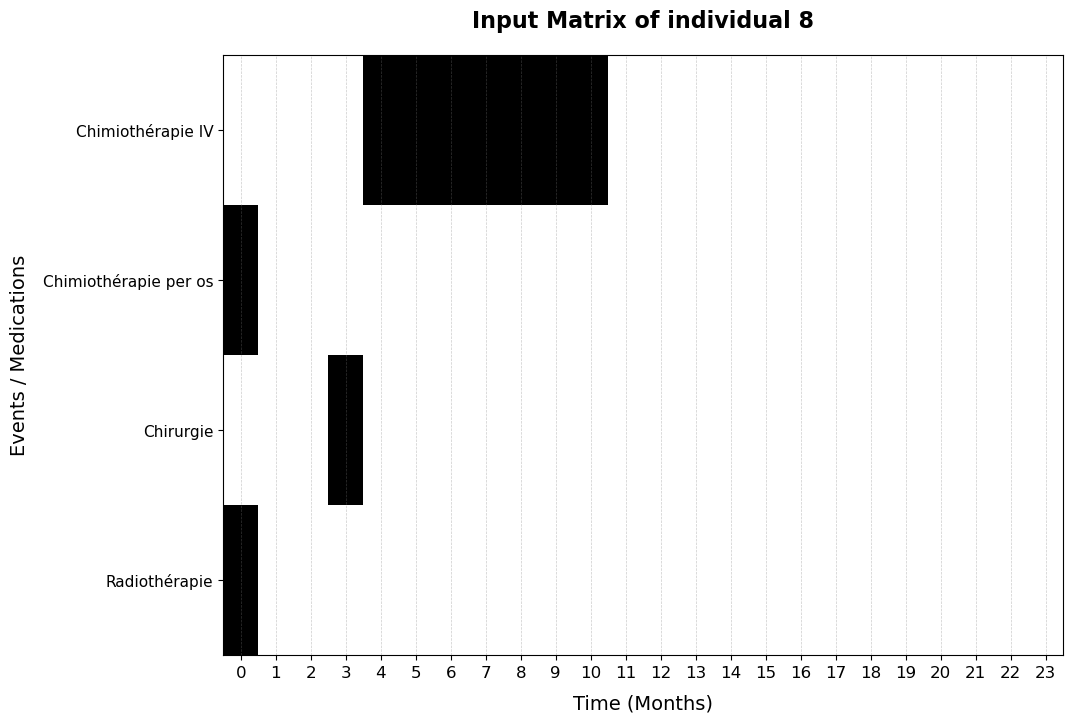

In [31]:
tca.analyzer.fit_swotted_decomposition(
        tensor=tensor,
        rank=rank,
        time_window_length=3,
        reg_term_ns=reg_term_ns,
        reg_term_s=reg_term_s,
        metric=metric,
        learning_rate=learning_rate,
        n_epochs=n_epochs
    )

tca.analyzer.get_decomposition_results(labels=noms_events, id=patient_index, time_unit="Months")

In [32]:
def compute_reconstruction(analyzer):
    model = analyzer.model
    X = analyzer.X
    
    X_pred = []
    for p in range(analyzer.K):
        X_pred.append(model.model.reconstruct(analyzer.W[p], model.Ph))
    
    return torch.stack(X_pred)

In [33]:
results = {}
saved_models = {}

ranks = [2, 3, 4]
windows = [2, 3, 4]

for rank in ranks:
    for tw in windows:
        print(f"Running rank={rank}, window={tw}")
        
        tca.analyzer.fit_swotted_decomposition(
            tensor=tensor,
            rank=rank,
            time_window_length=tw,
            reg_term_ns=0.5,
            reg_term_s=0.5,
            metric='Bernoulli',
            learning_rate=1e-3,
            n_epochs=3
        )
        
        X_pred = compute_reconstruction(tca.analyzer)

        saved_models[(rank, tw)] = {
            "model": tca.analyzer.model,
            "W": tca.analyzer.W,
            "X_pred": X_pred.detach().clone()
        }

        
        key = (rank, tw)
        results[key] = X_pred.detach().numpy()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 16     | n/a   | n/a  
--------------------------------------

Running rank=2, window=2


c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 24     | n/a   | n/a  
---------------------------------------------------------------
24        Trainable params
0         Non-trainable params
24        Total params
0.000     Total estimated model params size (MB)
1         

...

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 64     | n/a   | n/a  
---------------------------------------------------------------
64        Trainable params
0         Non-trainable params
64        Total params
0.000     Total estimated model params size (MB)
1         

Running rank=4, window=4


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.


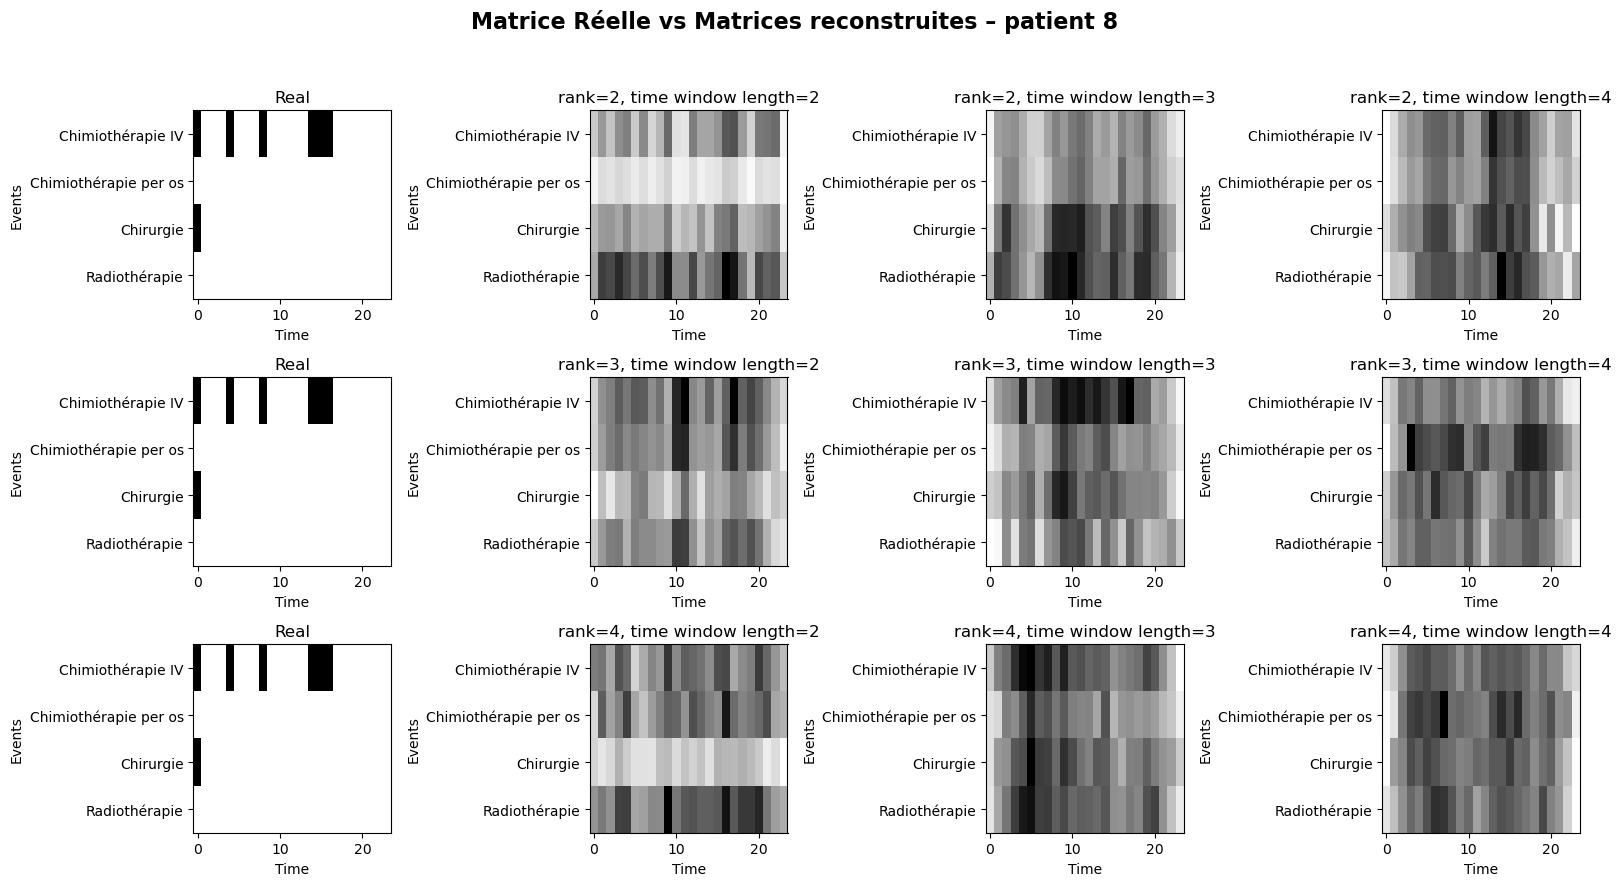

In [34]:
# Pour tracer les matrices reconstruites pour plusieurs rank et tailles de fenêtres sur un seul plot
def plot_matrix_on_ax(ax, matrix, labels, title=""):
    im = ax.imshow(matrix, aspect='auto', cmap='binary')
    
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels)
    
    ax.set_xlabel("Time")
    ax.set_ylabel("Events")
    
    ax.set_title(title)
    
    return im

fig, axes = plt.subplots(len(ranks), len(windows) + 1,
                         figsize=(4*(len(windows)+1), 3*len(ranks)))

true_tensor = tensor.numpy()

for i, rank in enumerate(ranks):
    
    # colonne 0 = vraie matrice du patient
    ax = axes[i, 0]
    plot_matrix_on_ax(
        ax,
        true_tensor[patient_index],
        noms_events,
        title=f"Real"
    )
    
    for j, tw in enumerate(windows):
        ax = axes[i, j+1]
        
        pred = results[(rank, tw)][patient_index]
        
        plot_matrix_on_ax(
            ax,
            pred,
            noms_events,
            title=f"rank={rank}, time window length={tw}"
        )


fig.suptitle(f"Matrice Réelle vs Matrices reconstruites – patient {patient_index}",
             fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

On choisit le rank et la taille de fenetre qui convient le mieux, et on affiche les phénotypes pour ce cas là.

Decomposed into 1336 pathways with rank 3 and time window length 3
FIT metric for the entire dataset: -2.0896
success_rate :-2.3798249713464115


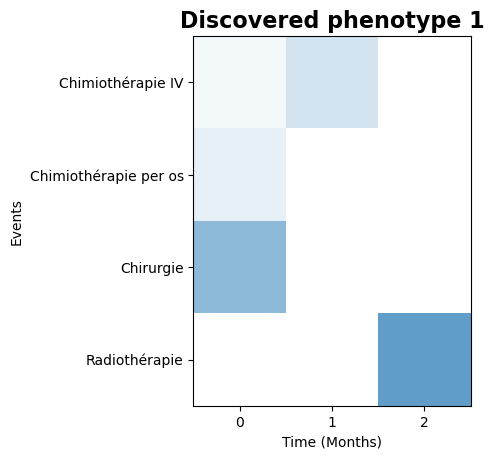

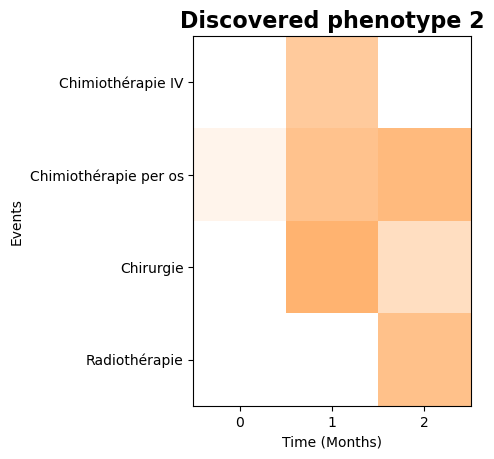

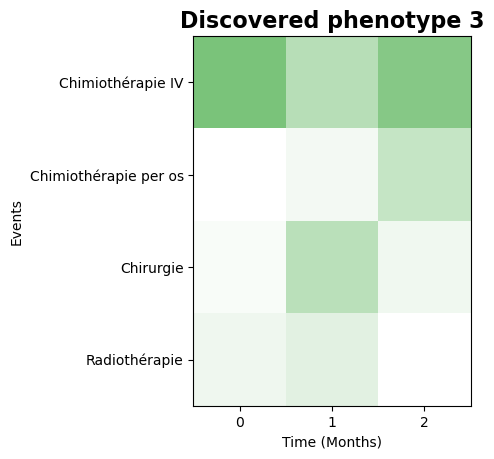

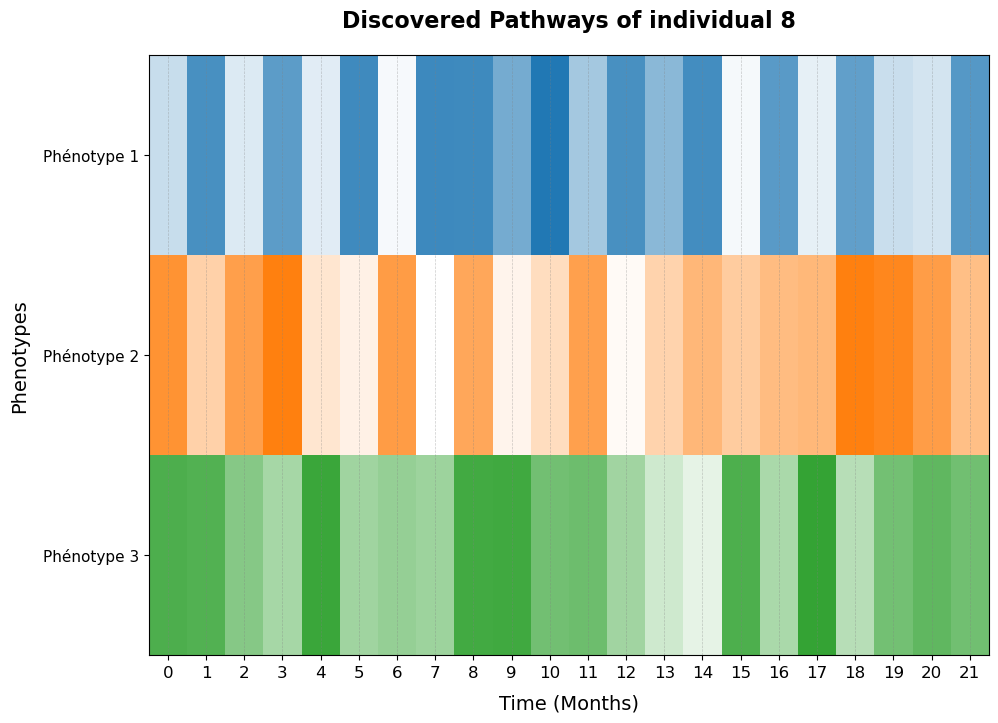

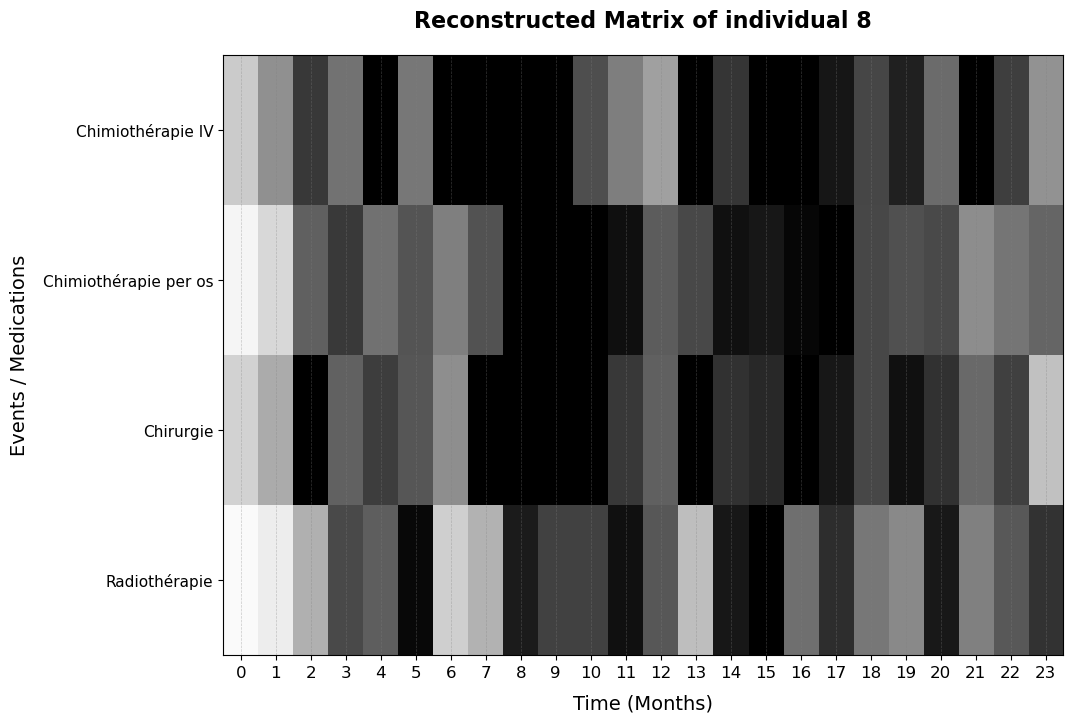

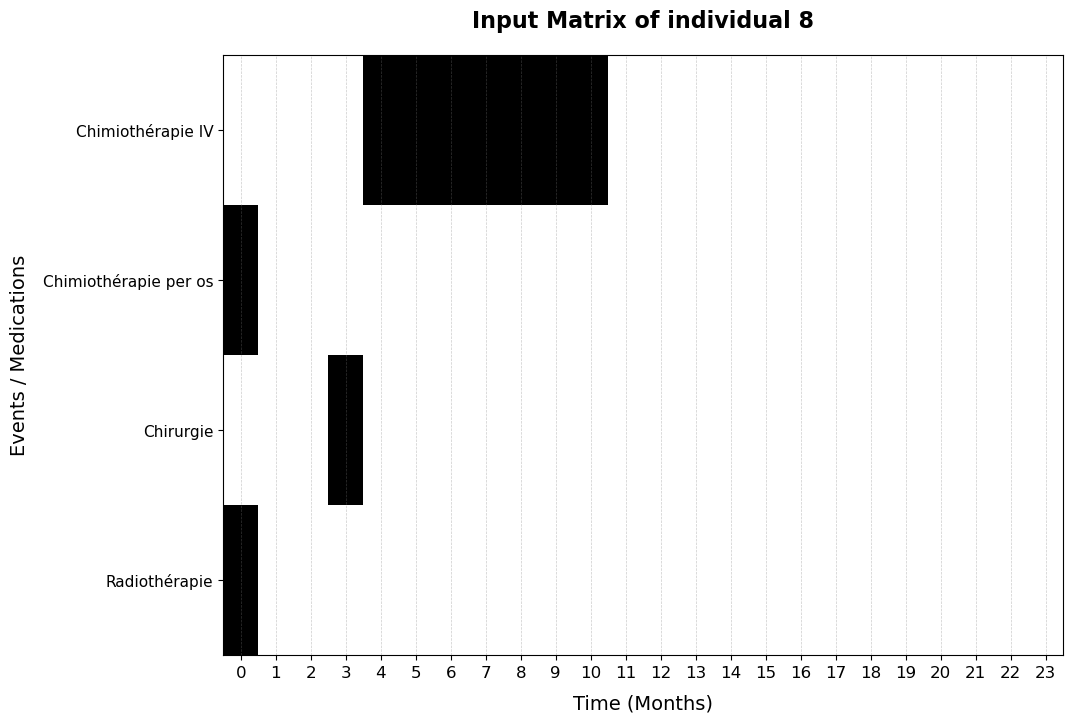

In [35]:
best_rank = 3
best_twl = 3

best = saved_models[(best_rank, best_twl)]

tca.analyzer.model = best["model"]
tca.analyzer.W = best["W"]

tca.analyzer.get_decomposition_results(
    labels=noms_events,
    id=patient_index
)

Une fois qu'on a les phénotypes, on peut faire un clustering.

## 5. Clustering

### 5.1. Intensités des phénotypes :

In [38]:
from sklearn.preprocessing import MinMaxScaler
ph_intensity = tca.analyzer.to_phenotype_intensity(scaler=MinMaxScaler())
print("Shape intensites:", ph_intensity.shape)
ph_intensity.head()

Shape intensites: (1336, 4)


,Phenotype_1,Phenotype_2,Phenotype_3,ID_PATIENT
0,0.519167,0.355648,0.351559,1
1,0.541737,0.738239,0.530511,2
2,0.459784,0.772571,0.534115,3
3,0.384052,0.312860,0.640890,4
4,0.332984,0.709780,0.301965,5


### 5.2. Clustering à partir des intensités

INFO:root:Calculating distance matrix using metric: euclidean...
INFO:root:Time taken for computation: 0.01 seconds
INFO:root:Computing the linkage matrix using method: ward...
c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src\trajectoryclusteringanalysis\unidimensional\clustering.py:238: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(condensed_distance_matrix, method=method, optimal_ordering=optimal_ordering)
INFO:root:Linkage matrix computed successfully


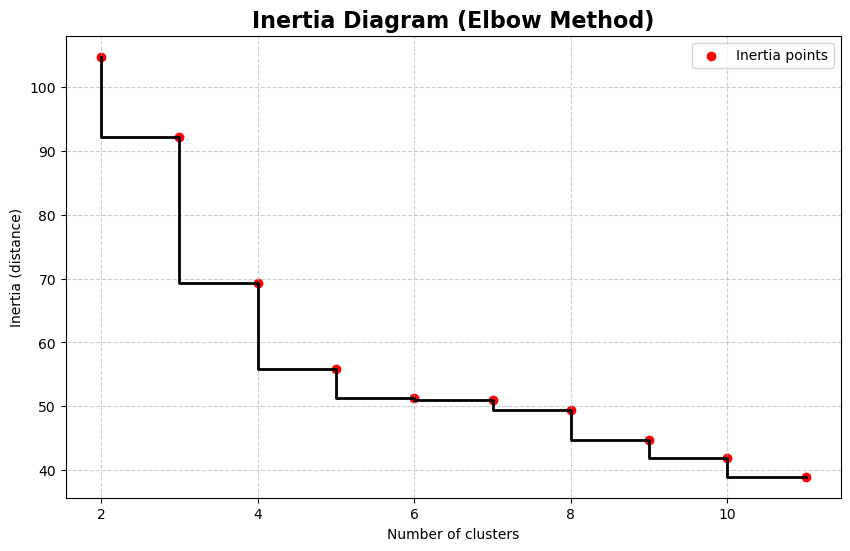

In [40]:
distance_matrix = tca.compute_distance_matrix(data=ph_intensity, metric='euclidean')
linkage_matrix = tca.hierarchical_clustering(distance_matrix)
tca.plot_inertia(linkage_matrix)

Il semble intéressant de chosir 4 clusters.

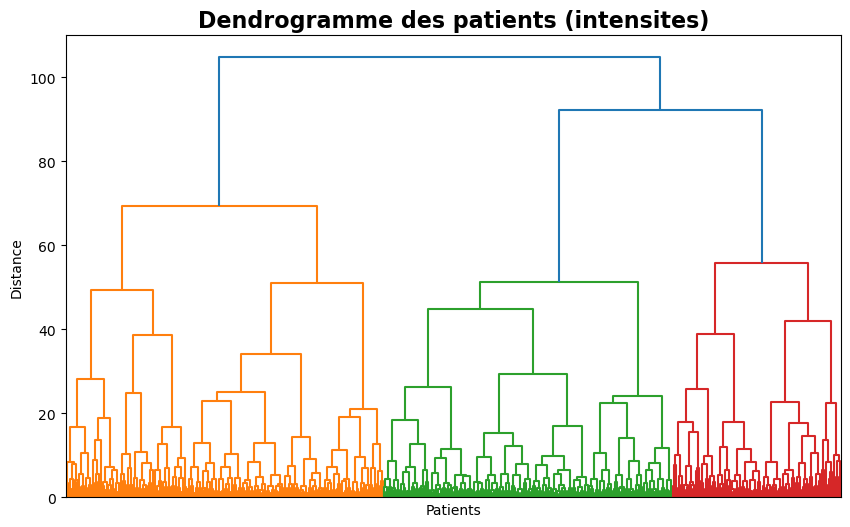

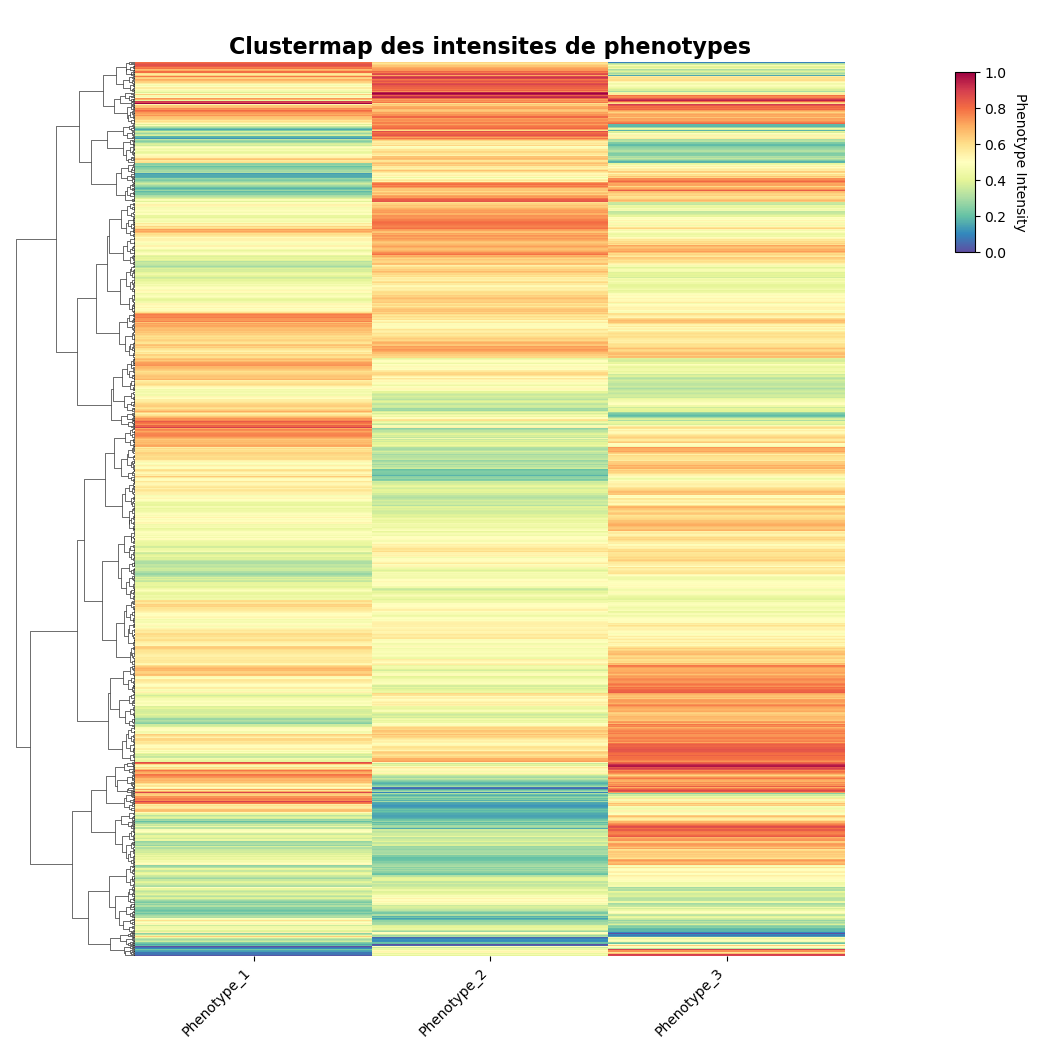

Effectifs par cluster:
1    209
2    338
3    499
4    290
Name: count, dtype: int64


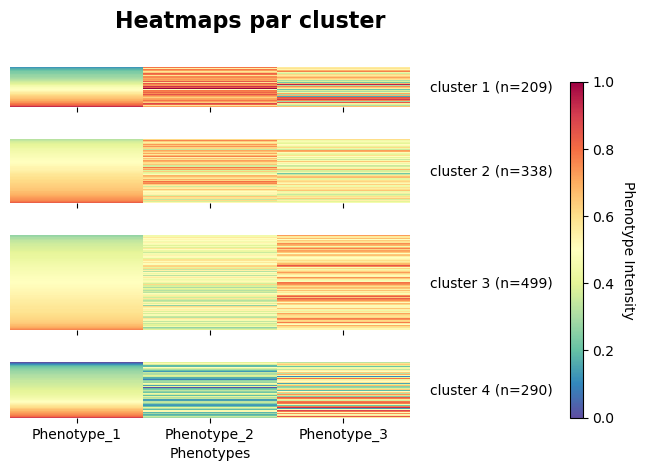

In [41]:
# Visualisations standard du package
tca.plot_dendrogram(linkage_matrix, title='Dendrogramme des patients (intensites)')
tca.plot_clustermap(ph_intensity, linkage_matrix, title='Clustermap des intensites de phenotypes')

clusters = tca.assign_clusters(linkage_matrix, num_clusters=4)
print("Effectifs par cluster:")
print(pd.Series(clusters).value_counts().sort_index())

tca.plot_cluster_heatmaps(ph_intensity, clusters, sorted=True, title='Heatmaps par cluster')